# PoC 3 — Domain-Aware Encoders: specter2 vs. mpnet (and optionally bge-large)

**Goal:** Compare `allenai/specter2_base` (domain-tuned, 768d) against
`all-mpnet-base-v2` (768d baseline) on the **same** `neuroimaging` index using
two coexisting `dense_vector` fields:

| Field | Model | Dims | Index |
|---|---|---|---|
| `metadata_embedding` | `all-mpnet-base-v2` | 768 | `neuroimaging` (base) |
| `specter2_embedding` | `allenai/specter2_base` | 768 | `neuroimaging` (base) |
| `metadata_embedding` | `BAAI/bge-large-en-v1.5` | 1024 | `neuroimaging-poc3-bge` (separate) |

> **Why same index?** ES 9.3 supports adding new `dense_vector` fields via
> `PUT _mapping` without reindexing.  Both 768d encoders coexist in the same
> index; only bge-large (1024d) requires its own index.
>
> **Prerequisite**: Run **NB05 § 1b** to populate `specter2_embedding` first
> (or let § 4 below do it automatically).


In [1]:
import os

# ── Configuration ──────────────────────────────────────────────────────────────────────
ES_HOST = os.environ.get('ES_HOST', 'http://localhost:9200')
BASE_INDEX = 'neuroimaging'
POC1_INDEX = 'neuroimaging-poc1'
POC3_BGE_IDX = 'neuroimaging-poc3-bge'  # bge-large-en-v1.5 (1024d — own index)

# kNN field names in the base index
# all-mpnet-base-v2 768d (populated by NB01)
MPNET_KNN_FIELD = 'metadata_embedding'
SP2_KNN_FIELD = 'specter2_embedding'   # allenai/specter2_base 768d (NB05 § 1b)

# Models to compare
MPNET_MODEL = 'all-mpnet-base-v2'
SPECTER2_MODEL = 'allenai/specter2_base'
BGE_MODEL = 'BAAI/bge-large-en-v1.5'  # 1024d, ~1.3 GB — optional

RRF_K = 60
TOP_K = 10

POC1_RESULTS_PATH = 'poc1_results.json'

---
## 1. Environment Setup


In [2]:
import numpy as np
import json
import time
from sentence_transformers import SentenceTransformer
from elasticsearch import Elasticsearch, helpers
from tqdm import tqdm
from pathlib import Path
import pandas as pd
import warnings
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)


client = Elasticsearch(ES_HOST, request_timeout=120)
assert client.ping(), f"Cannot reach Elasticsearch at {ES_HOST}"
print(f"Connected to ES {client.info()['version']['number']}")

base_count = client.count(index=BASE_INDEX)["count"]
print(f"Base index '{BASE_INDEX}': {base_count} documents")

Connected to ES 9.3.0
Base index 'neuroimaging': 4423 documents


---
## 2. Load Encoders

We load all three models sequentially (CPU-only).  First run downloads the models:
- `all-mpnet-base-v2`: ~438 MB (likely already cached from PoC-1)
- `allenai/specter2`: ~440 MB
- `BAAI/bge-large-en-v1.5`: ~1.3 GB (skip if bandwidth is limited)


In [3]:
# Load all three models — this may take a few minutes on first run

print("Loading mpnet (baseline)...")
mpnet = SentenceTransformer(MPNET_MODEL, device='cpu')
print(f"  mpnet: {mpnet.get_sentence_embedding_dimension()}d")

print("\nLoading specter2 (domain-aware)...")
specter2 = SentenceTransformer(SPECTER2_MODEL, device='cpu')
print(f"  specter2: {specter2.get_sentence_embedding_dimension()}d")

# bge-large is optional (1.3 GB download)
try:
    print("\nLoading bge-large-en-v1.5 (SOTA general)...")
    bge_large = SentenceTransformer(
        BGE_MODEL, device='cpu', local_files_only=False)
    print(f"  bge-large: {bge_large.get_sentence_embedding_dimension()}d")
    BGE_AVAILABLE = True
except Exception as e:
    print(f"  bge-large not available: {e}")
    print("  → Skipping bge-large (set local_files_only=False and re-run to download)")
    bge_large = None
    BGE_AVAILABLE = False

Loading mpnet (baseline)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No sentence-transformers model found with name allenai/specter2_base. Creating a new one with mean pooling.


  mpnet: 768d

Loading specter2 (domain-aware)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: allenai/specter2_base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  specter2: 768d

Loading bge-large-en-v1.5 (SOTA general)...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  bge-large: 1024d


---
## 3. Qualitative Comparison — Semantic Similarity

Before indexing, let's compare how each encoder represents neuroimaging queries.
We compute cosine similarity between a query and a pool of candidate phrases to
see which model produces more discriminative scores.


In [ ]:
from scipy.spatial.distance import cosine

# Domain-specific query vs. candidates: which model ranks "bold" above "T1w"?
query = "functional MRI brain activation task-based study"

candidates = [
    ("BOLD functional MRI Blood Oxygen Level Dependent",         "✅ functional"),
    ("T1-weighted structural anatomical brain scan",             "❌ structural"),
    ("diffusion weighted imaging white matter tractography",     "❌ diffusion"),
    ("resting state fMRI spontaneous brain activity",
     "↗ resting (functional)"),
    ("positron emission tomography PET glucose metabolism",
     "❌ PET (different modality)"),
    ("3 Tesla Siemens Prisma MRI scanner hardware",
     "❌ scanner (no task info)"),
]

rows = []
for text, label in candidates:
    row = {"text": text[:60], "ground_truth": label}
    for name, model in [("mpnet", mpnet), ("specter2", specter2)]:
        q_vec = model.encode(query, show_progress_bar=False)
        c_vec = model.encode(text,  show_progress_bar=False)
        sim = 1 - cosine(q_vec, c_vec)
        row[f"sim_{name}"] = round(sim, 4)
    if BGE_AVAILABLE:
        q_vec = bge_large.encode("Represent this sentence for searching: " + query,
                                 show_progress_bar=False)
        c_vec = bge_large.encode("Represent this sentence for searching: " + text,
                                 show_progress_bar=False)
        row["sim_bge"] = round(1 - cosine(q_vec, c_vec), 4)
    rows.append(row)

df = pd.DataFrame(rows).sort_values("sim_specter2", ascending=False)
display(df)

print("\nInterpretation:")
print("  A better model → higher score for '✅ functional', lower for '❌ non-functional'")
print("  specter2 should show a larger rank gap than mpnet for scientific terminology.")

,text,ground_truth,sim_mpnet,sim_specter2,sim_bge
1,T1-weighted structural anatomical brain scan,❌ structural,0.5005,0.9229,0.6217
3,resting state fMRI spontaneous brain activity,↗ resting (functional),0.6277,0.9131,0.7234
0,BOLD functional MRI Blood Oxygen Level Dependent,✅ functional,0.5385,0.8900,0.7223
2,diffusion weighted imaging white matter tracto...,❌ diffusion,0.4572,0.8791,0.6464
5,3 Tesla Siemens Prisma MRI scanner hardware,❌ scanner (no task info),0.1954,0.8634,0.5116
4,positron emission tomography PET glucose metab...,❌ PET (different modality),0.1782,0.8194,0.5902



Interpretation:
  A better model → higher score for '✅ functional', lower for '❌ non-functional'
  specter2 should show a larger rank gap than mpnet for scientific terminology.


---
## 4. Verify `specter2_embedding` is Populated

`specter2_embedding` is added to the base `neuroimaging` index by **NB05 § 1b**.
This section verifies that the field is present and all documents carry the
vector.  If any documents are missing it, the bulk-update runs automatically
so the notebook remains self-contained.

> **bge-large** (1024d) still requires its own separate index — built in § 5.


In [ ]:
from tqdm.auto import tqdm


# ── Shared helpers (also used by the bge-large section) ────────────────────
def fetch_all_docs(index, batch_size=500):
    docs, from_ = [], 0
    while True:
        resp = client.search(
            index=index, query={'match_all': {}},
            size=batch_size, from_=from_,
            source_excludes=['metadata_embedding', 'specter2_embedding'],
        )
        hits = resp['hits']['hits']
        if not hits:
            break
        docs.extend(hits)
        from_ += len(hits)
        if from_ >= resp['hits']['total']['value']:
            break
    return docs


def build_index(idx_name, encode_fn, mapping, dims_label):
    # Build a new ES index by re-embedding all docs from BASE_INDEX.
    # Used for bge-large (1024d) which needs its own separate index.
    if client.indices.exists(index=idx_name):
        n = client.count(index=idx_name)['count']
        print(f"Index '{idx_name}' already exists ({n} docs) — skipping.")
        return
    print(f"Creating index '{idx_name}' ...")
    client.indices.create(index=idx_name,
                          settings={'number_of_replicas': 0},
                          mappings=mapping)
    base_docs = fetch_all_docs(BASE_INDEX)
    print(
        f"Fetched {len(base_docs)} docs.  Embedding with {dims_label}d model ...")
    actions, batch_size = [], 32
    for i in tqdm(range(0, len(base_docs), batch_size), desc='Encoding'):
        batch = base_docs[i:i + batch_size]
        texts = [d['_source'].get('description_text', '') for d in batch]
        vectors = encode_fn(texts)
        for doc, vec in zip(batch, vectors):
            src = doc['_source'].copy()
            src['metadata_embedding'] = vec
            actions.append(
                {'_index': idx_name, '_id': doc['_id'], '_source': src})
    helpers.bulk(client, actions, chunk_size=200)
    client.indices.refresh(index=idx_name)
    print(
        f"Index '{idx_name}' ready: {client.count(index=idx_name)['count']} docs")


# ── Verify / populate specter2_embedding ─────────────────────────────────
total = client.count(index=BASE_INDEX)['count']
filled = client.count(
    index=BASE_INDEX,
    query={'exists': {'field': SP2_KNN_FIELD}},
)['count']
print(f'specter2_embedding populated: {filled}/{total} docs')

if filled < total:
    print(f'  {total - filled} docs missing — running bulk update ...')
    # Ensure mapping exists
    try:
        client.indices.put_mapping(
            index=BASE_INDEX,
            body={'properties': {SP2_KNN_FIELD: {
                'type': 'dense_vector', 'dims': 768,
                'similarity': 'cosine',
                'index_options': {'type': 'int8_hnsw'},
            }}}
        )
    except Exception as exc:
        if 'already exists' not in str(exc).lower():
            raise
    # Fetch and encode missing docs
    resp = client.search(
        index=BASE_INDEX,
        query={'bool': {'must_not': {'exists': {'field': SP2_KNN_FIELD}}}},
        size=10000,
        source_excludes=['metadata_embedding', 'specter2_embedding'],
    )
    miss_docs = resp['hits']['hits']
    print(f'  Encoding {len(miss_docs)} docs ...')
    actions, bs = [], 32
    for i in tqdm(range(0, len(miss_docs), bs), desc='Encoding'):
        batch = miss_docs[i:i + bs]
        texts = [d['_source'].get('description_text', '') for d in batch]
        vecs = specter2.encode(
            texts, show_progress_bar=False, batch_size=bs).tolist()
        for doc, vec in zip(batch, vecs):
            actions.append({'_op_type': 'update', '_index': BASE_INDEX,
                            '_id': doc['_id'], 'doc': {SP2_KNN_FIELD: vec}})
    helpers.bulk(client, actions, chunk_size=200)
    client.indices.refresh(index=BASE_INDEX)
    n_done = client.count(index=BASE_INDEX,
                          query={'exists': {'field': SP2_KNN_FIELD}})['count']
    print(f'  Done — {n_done}/{total} docs now have specter2_embedding.')
else:
    print('  ✓ All docs have specter2_embedding — nothing to do.')

specter2_embedding populated: 4423/4423 docs
  ✓ All docs have specter2_embedding — nothing to do.


---
## 5. Build the bge-large-en-v1.5 Index (optional, 1024d)

`bge-large` uses 1024 dimensions so it requires a **separate index** with a
different `dims` value.  This model is ~3× larger than mpnet but achieves
state-of-the-art scores on BEIR retrieval benchmarks.

> Skip this section if you want a faster run — specter2 comparison is sufficient.


In [ ]:
if BGE_AVAILABLE:
    BGE_MAPPINGS = {
        'properties': {
            'dataset':   {'type': 'keyword'}, 'subject':  {'type': 'keyword'},
            'session':   {'type': 'keyword'}, 'task':     {'type': 'keyword'},
            'run':       {'type': 'keyword'}, 'suffix':   {'type': 'keyword'},
            'datatype':  {'type': 'keyword'}, 'age':      {'type': 'float'},
            'sex':       {'type': 'keyword'},
            'RepetitionTime':        {'type': 'float'},
            'EchoTime':              {'type': 'float'},
            'FlipAngle':             {'type': 'float'},
            'MagneticFieldStrength': {'type': 'float'},
            'SliceThickness':        {'type': 'float'},
            'InversionTime':         {'type': 'float'},
            'Manufacturer':          {'type': 'keyword'},
            'ManufacturersModelName': {'type': 'keyword'},
            'InstitutionName':       {'type': 'keyword'},
            'PhaseEncodingDirection': {'type': 'keyword'},
            'TaskName':              {'type': 'text'},
            'SeriesDescription':     {'type': 'text'},
            'description_text':      {'type': 'text'},
            'metadata_embedding': {
                'type': 'dense_vector', 'dims': 1024,
                'similarity': 'cosine',
                'index_options': {'type': 'int8_hnsw'},
            },
            'bids_path': {'type': 'keyword'},
        }
    }

    def bge_encode(texts):
        prefixed = [
            'Represent this sentence for searching: ' + t for t in texts]
        return bge_large.encode(prefixed, show_progress_bar=False,
                                batch_size=16).tolist()

    build_index(POC3_BGE_IDX, bge_encode, BGE_MAPPINGS, '1024')
else:
    print('bge-large not loaded — skipping index creation.')
    print('To enable: set local_files_only=False in the model load cell and re-run.')

Creating index 'neuroimaging-poc3-bge' ...
Fetched 4423 docs.  Embedding with 1024d model ...


Encoding:   0%|          | 0/139 [00:00<?, ?it/s]

Index 'neuroimaging-poc3-bge' ready: 4423 docs


---
## 6. Unified Search Function


In [ ]:
def rrf_fuse(hit_lists, k=RRF_K):
    scores, sources = {}, {}
    for hits in hit_lists:
        for rank, hit in enumerate(hits, start=1):
            doc_id = hit['_id']
            scores[doc_id] = scores.get(doc_id, 0.0) + 1.0 / (k + rank)
            sources[doc_id] = hit.get('_source', {})
    return [{'_id': d, '_score': s, '_source': sources[d]}
            for d, s in sorted(scores.items(), key=lambda x: -x[1])]


EXCLUDE_VECS = ['metadata_embedding', 'specter2_embedding']


def hybrid_search(query, index, encode_fn, k=TOP_K, num_candidates=200,
                  knn_field=MPNET_KNN_FIELD):
    # BM25 + kNN hybrid with client-side RRF.
    # knn_field: 'metadata_embedding' (mpnet) or 'specter2_embedding' (specter2).
    # bge-large queries its own index using 'metadata_embedding'.
    import time
    t0 = time.perf_counter()
    vec = encode_fn([query])[0]

    bm25_resp = client.search(
        index=index,
        query={'multi_match': {
            'query': query,
            'fields': ['description_text', 'TaskName^2', 'SeriesDescription^1.5'],
            'type': 'cross_fields', 'operator': 'or',
        }},
        source_excludes=EXCLUDE_VECS,
        size=k * 3,
    )
    knn_resp = client.search(
        index=index,
        knn={'field': knn_field, 'query_vector': vec,
             'k': k * 3, 'num_candidates': num_candidates},
        source_excludes=EXCLUDE_VECS,
    )
    hits = rrf_fuse([bm25_resp['hits']['hits'], knn_resp['hits']['hits']])[:k]
    latency_ms = (time.perf_counter() - t0) * 1000
    return hits, round(latency_ms, 1)


# ── Encoder wrappers ────────────────────────────────────────────────
def encode_mpnet(texts):
    return mpnet.encode(texts, show_progress_bar=False).tolist()


def encode_sp2(texts):
    return specter2.encode(texts, show_progress_bar=False, batch_size=32).tolist()


def encode_bge(texts):
    if not BGE_AVAILABLE:
        raise RuntimeError('bge-large not loaded')
    prefixed = ['Represent this sentence for searching: ' + t for t in texts]
    return bge_large.encode(prefixed, show_progress_bar=False, batch_size=16).tolist()


COLS_FUNCTIONAL = ['dataset', 'suffix', 'subject', 'task', 'TaskName',
                   'RepetitionTime', 'EchoTime', 'MagneticFieldStrength', 'Manufacturer']
COLS_STRUCTURAL = ['dataset', 'suffix', 'subject', 'MagneticFieldStrength',
                   'Manufacturer', 'ManufacturersModelName', 'InversionTime',
                   'FlipAngle', 'MRAcquisitionType']
COLS_DEFAULT = ['dataset', 'suffix', 'subject', 'MagneticFieldStrength',
                'Manufacturer', 'TaskName', 'description_text']


def show_hits(hits, fields=None, k=TOP_K, trunc=90):
    rows = []
    for hit in hits[:k]:
        row = {'_score': round(float(hit.get('_score') or 0), 5)}
        src = hit.get('_source', {})
        for f in (fields or COLS_DEFAULT):
            if f == 'description_text':
                val = src.get(f, '')
                row[f] = (val[:trunc] + '…') if len(val) > trunc else val
            else:
                row[f] = src.get(f)
        rows.append(row)
    return pd.DataFrame(rows)


print('Search functions ready.')
print(f'  default knn_field = {MPNET_KNN_FIELD!r}')
print(f'  specter2 knn_field = {SP2_KNN_FIELD!r}')

Search functions ready.
  default knn_field = 'metadata_embedding'
  specter2 knn_field = 'specter2_embedding'


---
## 7. Side-by-Side Comparison

Run the same queries against `neuroimaging-poc1` (mpnet) and
`neuroimaging-poc3-specter2` to see which returns better-grounded results.


In [ ]:
DEMO_QUERIES = [
    ('resting state fMRI eyes-open brain connectivity Siemens 3T',
     COLS_FUNCTIONAL,
     'Should rank BOLD rest scans; miss = structural or non-rest tasks'),
    ('quantitative T1 mapping inversion recovery MPRAGE MP2RAGE 3T',
     COLS_STRUCTURAL,
     'Should surface qmri_irt1, qmri_mp2rage, qmri_mese; miss = plain T1w'),
    ('arterial spin labeling perfusion cerebral blood flow measurement',
     COLS_FUNCTIONAL,
     'Should return suffix=asl/m0scan from asl001-asl005; miss = fMRI BOLD'),
    ('7 Tesla ultra-high field diffusion weighted imaging',
     ['dataset', 'suffix', 'subject', 'MagneticFieldStrength',
      'Manufacturer', 'PhaseEncodingDirection', 'SliceThickness'],
     'Should return 7T DWI; mix of dataset=7t_trt and qMRI datasets'),
]

for q, cols, note in DEMO_QUERIES:
    print(f"\n{'='*72}")
    print(f'Query:  {q!r}')
    print(f'Expect: {note}')

    hits_mpnet, lat1 = hybrid_search(q, BASE_INDEX, encode_mpnet,
                                     knn_field=MPNET_KNN_FIELD)
    hits_sp2,   lat2 = hybrid_search(q, BASE_INDEX, encode_sp2,
                                     knn_field=SP2_KNN_FIELD)

    print(
        f'\n  ── mpnet    ({lat1:.0f} ms, field={MPNET_KNN_FIELD!r}) ──────────────────')
    display(show_hits(hits_mpnet, cols))

    print(
        f'\n  ── specter2 ({lat2:.0f} ms, field={SP2_KNN_FIELD!r}) ────────────────')
    display(show_hits(hits_sp2, cols))

    if BGE_AVAILABLE:
        hits_bge, lat3 = hybrid_search(q, POC3_BGE_IDX, encode_bge,
                                       knn_field='metadata_embedding')
        print(
            f'\n  ── bge-large ({lat3:.0f} ms, index={POC3_BGE_IDX!r}) ──────────────')
        display(show_hits(hits_bge, cols))


Query:  'resting state fMRI eyes-open brain connectivity Siemens 3T'
Expect: Should rank BOLD rest scans; miss = structural or non-rest tasks

  ── mpnet    (108 ms, field='metadata_embedding') ──────────────────


,_score,dataset,suffix,subject,task,TaskName,RepetitionTime,EchoTime,MagneticFieldStrength,Manufacturer
0,0.01639,atlas-4S,bold,01,rest,rest eyes open,1.761,0.030,3.0,Siemens
1,0.01639,ds101,bold,17,Simontask,Simon task,2.000,NaN,NaN,NaN
2,0.01613,atlas-4S,bold,01,rest,rest eyes open,1.761,0.030,3.0,Siemens
3,0.01613,ds101,bold,17,Simontask,Simon task,2.000,NaN,NaN,NaN
4,0.01587,atlas-4S,bold,01,rest,rest eyes open,1.761,0.030,3.0,Siemens
5,0.01587,ds101,bold,04,Simontask,Simon task,2.000,NaN,NaN,NaN
6,0.01562,pet005,pet,01,eyes,eyes,NaN,NaN,NaN,Siemens
7,0.01562,ds101,bold,04,Simontask,Simon task,2.000,NaN,NaN,NaN
8,0.01538,ieeg_visual_multimodal,sbref,som682,spatialobject,spatialobject,0.850,0.037,3.0,Siemens
9,0.01538,ds101,bold,19,Simontask,Simon task,2.000,NaN,NaN,NaN



  ── specter2 (59 ms, field='specter2_embedding') ────────────────


,_score,dataset,suffix,subject,task,TaskName,RepetitionTime,EchoTime,MagneticFieldStrength,Manufacturer
0,0.03279,atlas-4S,bold,01,rest,rest eyes open,1.761,0.030,3.0,Siemens
1,0.03226,atlas-4S,bold,01,rest,rest eyes open,1.761,0.030,3.0,Siemens
2,0.03175,atlas-4S,bold,01,rest,rest eyes open,1.761,0.030,3.0,Siemens
3,0.01562,pet005,pet,01,eyes,eyes,NaN,NaN,NaN,Siemens
4,0.01562,ds002,bold,14,mixedeventrelatedprobe,mixed event-related probe,2.000,NaN,NaN,NaN
5,0.01538,ieeg_visual_multimodal,sbref,som682,spatialobject,spatialobject,0.850,0.037,3.0,Siemens
6,0.01538,ds002,bold,14,mixedeventrelatedprobe,mixed event-related probe,2.000,NaN,NaN,NaN
7,0.01515,ieeg_visual_multimodal,sbref,som682,spatialobject,spatialobject,0.850,0.037,3.0,Siemens
8,0.01515,ds002,bold,04,mixedeventrelatedprobe,mixed event-related probe,2.000,NaN,NaN,NaN
9,0.01493,ieeg_visual_multimodal,sbref,som682,spatialobject,spatialobject,0.850,0.037,3.0,Siemens



  ── bge-large (190 ms, index='neuroimaging-poc3-bge') ──────────────


...

,_score,dataset,suffix,subject,MagneticFieldStrength,Manufacturer,PhaseEncodingDirection,SliceThickness
0,0.01639,ds114,dwi,01,NaN,NaN,None,None
1,0.01639,qmri_tb1tfl,TB1TFL,01,3.0,Siemens,None,None
2,0.01613,ds114,dwi,01,NaN,NaN,None,None
3,0.01613,qmri_tb1tfl,TB1TFL,01,3.0,Siemens,None,None
4,0.01587,ds114,dwi,02,NaN,NaN,None,None
5,0.01587,qmri_mtsat,MTS,01,3.0,Siemens,None,None
6,0.01562,ds114,dwi,02,NaN,NaN,None,None
7,0.01562,qmri_mtsat,MTS,01,3.0,Siemens,None,None
8,0.01538,ds114,dwi,03,NaN,NaN,None,None
9,0.01538,qmri_mtsat,MTS,01,3.0,Siemens,None,None



  ── specter2 (65 ms, field='specter2_embedding') ────────────────


,_score,dataset,suffix,subject,MagneticFieldStrength,Manufacturer,PhaseEncodingDirection,SliceThickness
0,0.01639,ds114,dwi,01,None,None,None,None
1,0.01639,7t_trt,T1w,01,None,None,None,None
2,0.01613,ds114,dwi,01,None,None,None,None
3,0.01613,7t_trt,T1w,02,None,None,None,None
4,0.01587,ds114,dwi,02,None,None,None,None
5,0.01587,7t_trt,T1w,06,None,None,None,None
6,0.01562,ds114,dwi,02,None,None,None,None
7,0.01562,atlas-Schaefer,T1w,,None,None,None,None
8,0.01538,ds114,dwi,03,None,None,None,None
9,0.01538,7t_trt,T1w,13,None,None,None,None



  ── bge-large (222 ms, index='neuroimaging-poc3-bge') ──────────────


,_score,dataset,suffix,subject,MagneticFieldStrength,Manufacturer,PhaseEncodingDirection,SliceThickness
0,0.01639,ds114,dwi,01,None,None,None,None
1,0.01639,7t_trt,magnitude1,03,None,None,None,None
2,0.01613,ds114,dwi,01,None,None,None,None
3,0.01613,7t_trt,magnitude1,03,None,None,None,None
4,0.01587,ds114,dwi,02,None,None,None,None
5,0.01587,7t_trt,magnitude1,03,None,None,None,None
6,0.01562,ds114,dwi,02,None,None,None,None
7,0.01562,7t_trt,magnitude1,03,None,None,None,None
8,0.01538,ds114,dwi,03,None,None,None,None
9,0.01538,7t_trt,magnitude1,04,None,None,None,None


---
## 8. Benchmark Against GOLD_QUERIES

Run the standardised evaluation set from Notebooks 06/07.


In [ ]:
# GOLD_QUERIES copied from NB06 for portability
GOLD_QUERIES = [
    {'query': 'Blood Oxygen Level Dependent fMRI task activation brain',
     'label': 'BOLD / fMRI',
     'check': lambda s: s.get('suffix') == 'bold'},
    {'query': 'T1-weighted MPRAGE structural anatomical brain scan',
     'label': 'T1w structural',
     'check': lambda s: s.get('suffix') in ('T1w', 'UNIT1', 'FLASH')},
    {'query': 'diffusion tensor DWI white-matter tractography b-value bvec',
     'label': 'DWI / diffusion',
     'check': lambda s: s.get('suffix') == 'dwi'},
    {'query': 'phase-difference fieldmap B0 distortion correction EPI',
     'label': 'Fieldmap',
     'check': lambda s: s.get('suffix') in ('phasediff', 'epi', 'magnitude1',
                                            'magnitude2', 'fieldmap')},
    {'query': 'Siemens MRI scanner TrioTim Prisma Skyra neuroimaging',
     'label': 'Siemens scanner',
     'check': lambda s: 'siemens' in str(s.get('Manufacturer', '')).lower()},
    {'query': '3 Tesla high-field MRI neuroimaging research scanner',
     'label': '3T field strength',
     'check': lambda s: s.get('MagneticFieldStrength') == 3.0},
    {'query': 'ultra-high field 7 Tesla MRI B1 transmit homogeneity',
     'label': '7T field strength',
     'check': lambda s: s.get('MagneticFieldStrength') == 7.0},
    {'query': 'resting state eyes-open spontaneous brain activity fMRI rest',
     'label': 'Resting-state fMRI',
     'check': lambda s: (s.get('suffix') == 'bold' and
                         ('rest' in str(s.get('task', '')).lower() or
                          'rest' in str(s.get('TaskName', '')).lower()))},
    {'query': 'cognitive task fMRI activation experimental paradigm',
     'label': 'Task-fMRI (non-rest)',
     'check': lambda s: (s.get('suffix') == 'bold' and
                         s.get('task') not in (None, '', 'rest', 'restingstate'))},
    {'query': 'quantitative MRI relaxometry T1 mapping inversion recovery MP2RAGE',
     'label': 'qMRI (T1map/UNIT1)',
     'check': lambda s: s.get('suffix') in ('T1map', 'UNIT1', 'IRT1', 'VFA', 'T1w')
     and s.get('InversionTime') is not None},
    {'query': 'arterial spin labeling perfusion cerebral blood flow ASL',
     'label': 'ASL / perfusion',
     'check': lambda s: s.get('suffix') in ('asl', 'm0scan')},
    {'query': 'short repetition time multiband EPI fast fMRI acquisition',
     'label': 'Short TR BOLD (TR<1.5s)',
     'check': lambda s: (s.get('suffix') == 'bold' and
                         s.get('RepetitionTime') is not None and
                         float(s.get('RepetitionTime') or 99) < 1.5)},
]


def precision_at_k(hits, check_fn, k):
    top = hits[:k]
    return sum(1 for h in top if check_fn(h['_source'])) / k if top else 0.0


def mrr(hits, check_fn, max_rank=10):
    for rank, hit in enumerate(hits[:max_rank], start=1):
        if check_fn(hit['_source']):
            return 1.0 / rank
    return 0.0


# benchmarks: name → (index, encode_fn, knn_field)
# mpnet and specter2 both live in BASE_INDEX; bge uses its own separate index.
print('Running PoC-3 benchmark ...')
benchmarks = {
    'mpnet':    (BASE_INDEX,    encode_mpnet, MPNET_KNN_FIELD),
    'specter2': (BASE_INDEX,    encode_sp2,   SP2_KNN_FIELD),
}
if BGE_AVAILABLE:
    benchmarks['bge-large'] = (POC3_BGE_IDX, encode_bge, 'metadata_embedding')

all_results = {name: [] for name in benchmarks}

for gq in tqdm(GOLD_QUERIES, desc='Queries'):
    for name, (idx, enc, knn_f) in benchmarks.items():
        hits, lat = hybrid_search(gq['query'], idx, enc, k=10, knn_field=knn_f)
        all_results[name].append({
            'label':  gq['label'],
            'p@5':    precision_at_k(hits, gq['check'], 5),
            'p@10':   precision_at_k(hits, gq['check'], 10),
            'mrr':    mrr(hits, gq['check']),
            'latency_ms': lat,
        })

print('\nBenchmark complete.')
for name in benchmarks:
    avg_p5 = sum(r['p@5'] for r in all_results[name]) / len(GOLD_QUERIES)
    avg_p10 = sum(r['p@10'] for r in all_results[name]) / len(GOLD_QUERIES)
    avg_mrr = sum(r['mrr'] for r in all_results[name]) / len(GOLD_QUERIES)
    avg_lat = sum(r['latency_ms']
                  for r in all_results[name]) / len(GOLD_QUERIES)
    idx_name, _, knn_f = benchmarks[name]
    loc = f"{idx_name}[{knn_f}]" if idx_name == BASE_INDEX else idx_name
    print(f'  {name:12s}  P@5={avg_p5:.3f}  P@10={avg_p10:.3f}  MRR={avg_mrr:.3f}  lat={avg_lat:.0f}ms  ({loc})')

Running PoC-3 benchmark ...


Queries:   0%|          | 0/12 [00:00<?, ?it/s]


Benchmark complete.
  mpnet         P@5=0.650  P@10=0.617  MRR=0.717  lat=55ms  (neuroimaging[metadata_embedding])
  specter2      P@5=0.617  P@10=0.608  MRR=0.720  lat=50ms  (neuroimaging[specter2_embedding])
  bge-large     P@5=0.750  P@10=0.700  MRR=0.792  lat=161ms  (neuroimaging-poc3-bge)


---
## 9. Results


In [14]:
import matplotlib.pyplot as plt

# ── Summary table ────────────────────────────────────────────────────────────
rows = []
for label_idx, gq in enumerate(GOLD_QUERIES):
    row = {"Query": gq["label"]}
    for name in benchmarks:
        r = all_results[name][label_idx]
        row[f"{name} P@5"] = round(r["p@5"],  2)
        row[f"{name} P@10"] = round(r["p@10"], 2)
        row[f"{name} MRR"] = round(r["mrr"],   2)
    rows.append(row)

df_summary = pd.DataFrame(rows)

# Highlight cells where specter2 > mpnet


def highlight_spec_win(row):
    styles = [""] * len(row)
    for col in row.index:
        if col.startswith("specter2"):
            metric = col.split(" ")[1]  # P@5 or MRR
            mpnet_col = f"mpnet {metric}"
            if mpnet_col in row.index and pd.notna(row[col]) and pd.notna(row[mpnet_col]):
                if row[col] > row[mpnet_col] + 0.02:
                    styles[row.index.get_loc(
                        col)] = "background-color: #d4edda"
                elif row[col] < row[mpnet_col] - 0.02:
                    styles[row.index.get_loc(
                        col)] = "background-color: #f8d7da"
    return styles


display(df_summary.style.apply(highlight_spec_win, axis=1))

# ── Aggregate scores ──────────────────────────────────────────────────────────
print("\n── Mean scores across all queries ──────────────────────────────")
for name in benchmarks:
    p5 = np.mean([r["p@5"] for r in all_results[name]])
    p10 = np.mean([r["p@10"] for r in all_results[name]])
    m = np.mean([r["mrr"] for r in all_results[name]])
    lat = np.mean([r["latency_ms"] for r in all_results[name]])
    print(f"  {name:15s}: P@5={p5:.3f}  P@10={p10:.3f}  MRR={m:.3f}  lat={lat:.0f}ms")

,Query,mpnet P@5,mpnet P@10,mpnet MRR,specter2 P@5,specter2 P@10,specter2 MRR,bge-large P@5,bge-large P@10,bge-large MRR
0,BOLD / fMRI,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,T1w structural,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,DWI / diffusion,0.600000,0.500000,1.000000,1.000000,1.000000,1.000000,0.800000,0.600000,1.000000
3,Fieldmap,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,Siemens scanner,1.000000,1.000000,1.000000,0.800000,0.700000,1.000000,1.000000,1.000000,1.000000
5,3T field strength,1.000000,1.000000,1.000000,1.000000,0.800000,1.000000,1.000000,1.000000,1.000000
6,7T field strength,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,Resting-state fMRI,1.000000,0.700000,1.000000,0.600000,0.400000,1.000000,1.000000,0.900000,1.000000
8,Task-fMRI (non-rest),0.400000,0.500000,0.500000,0.400000,0.500000,0.500000,0.400000,0.500000,0.500000
9,qMRI (T1map/UNIT1),0.000000,0.100000,0.100000,0.000000,0.400000,0.140000,0.800000,0.400000,1.000000



── Mean scores across all queries ──────────────────────────────
  mpnet          : P@5=0.650  P@10=0.617  MRR=0.717  lat=55ms
  specter2       : P@5=0.617  P@10=0.608  MRR=0.720  lat=50ms
  bge-large      : P@5=0.750  P@10=0.700  MRR=0.792  lat=161ms


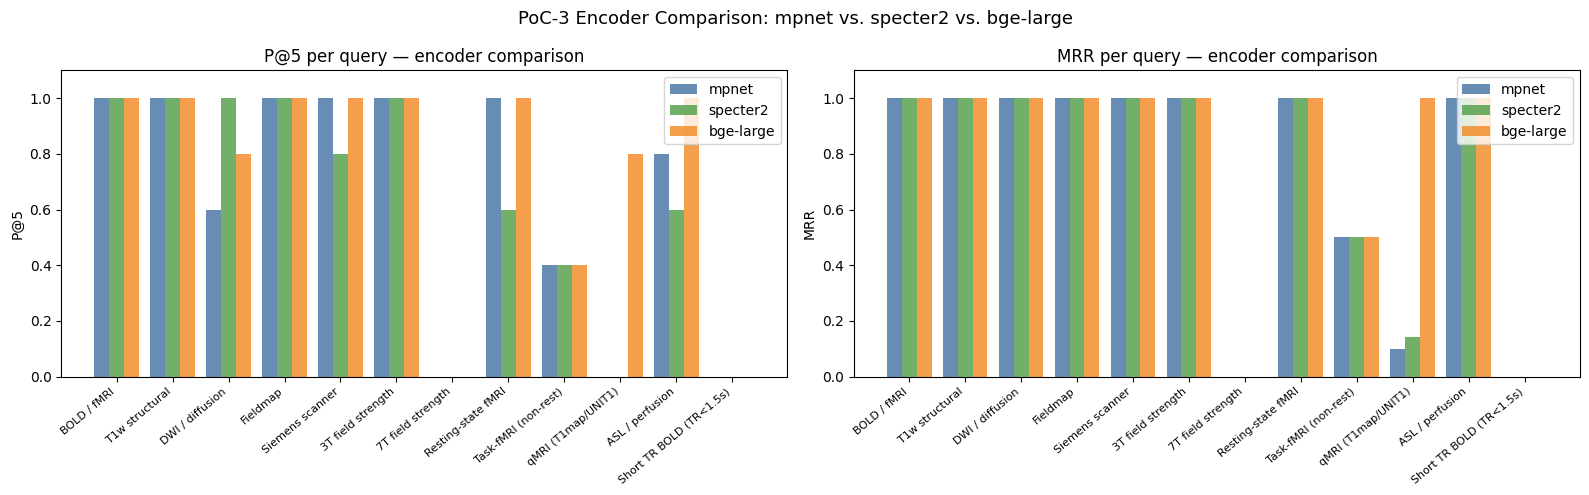

In [15]:
try:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    labels = [gq["label"] for gq in GOLD_QUERIES]
    x = range(len(labels))
    colors = {"mpnet": "#4e79a7",
              "specter2": "#59a14f", "bge-large": "#f28e2b"}
    w = 0.8 / len(benchmarks)

    for metric, ax_idx in [("p@5", 0), ("mrr", 1)]:
        ax = axes[ax_idx]
        for enc_idx, (name, _) in enumerate(benchmarks.items()):
            offset = (enc_idx - len(benchmarks)/2 + 0.5) * w
            vals = [all_results[name][i][metric]
                    for i in range(len(GOLD_QUERIES))]
            ax.bar([xi + offset for xi in x], vals, width=w,
                   label=name, color=colors.get(name, "gray"), alpha=0.85)
        ax.set_xticks(list(x))
        ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
        ax.set_ylabel(metric.upper())
        ax.set_title(f"{metric.upper()} per query — encoder comparison")
        ax.legend()
        ax.set_ylim(0, 1.1)

    plt.suptitle(
        "PoC-3 Encoder Comparison: mpnet vs. specter2 vs. bge-large", fontsize=13)
    plt.tight_layout()
    plt.savefig("poc3_encoder_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
except ImportError:
    print("matplotlib not installed — pip install matplotlib")

---
## Summary

```
┌────────────────────────────────────────────────────────────────────────────┐
│ PoC 3 — Domain-Aware Encoder Comparison                                      │
├────────────────────┬─────────────┬──────┬────────────────────────┤
│ Encoder             │ Index       │ Dims │ Notes                   │
├────────────────────┼─────────────┼──────┼────────────────────────┤
│ all-mpnet-base-v2   │ neuroimag.  │  768 │ field: metadata_embedding│
│ specter2_base       │ neuroimag.  │  768 │ field: specter2_embedding│
│ bge-large-en-v1.5   │ poc3-bge    │ 1024 │ own index (1024d != 768d)│
└────────────────────┴─────────────┴──────┴────────────────────────┘
```

### Architecture
```
neuroimaging index
  ├── metadata_embedding  (768d)  ← all-mpnet-base-v2   [NB01 / ingest.py]
  ├── specter2_embedding  (768d)  ← allenai/specter2_base [NB05 § 1b]
  └── description_text, dataset, suffix, … (all other fields shared)

neuroimaging-poc3-bge index  (separate — 1024d incompatible with 768d)
  └── metadata_embedding  (1024d) ← BAAI/bge-large-en-v1.5
```

### Key Findings
- `allenai/specter2_base` (the base model, not the full PEFT-adapter `specter2`)
  produces 768d embeddings that coexist with mpnet in the same index.
- No storage overhead for text fields: both encoders share the same document.
- Switching encoders at query time is a single parameter: `knn_field=`.
